In [18]:
# importing all the required libarries)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

In [19]:
#reading in the data
df = pd.read_csv('Walmart_Sales.csv')

In [20]:
#Converting dates (strings to date-time format), so that we can extract month, and day status (which are 2 of our independant variables)
df['Date'] = pd.to_datetime(df['Date'], dayfirst = True)
df['Month'] = df['Date'].dt.month

df['Day'] = df['Date'].dt.day

def get_day_status(day):
    if 1 <= day <= 10:
        return 'Month_Start'
    elif 11 <= day <= 20:
        return 'Month_Middle'
    else:
        return 'Month_End'
df['Day_Status'] = df['Day'].apply(get_day_status)#runnning the function over all the days


In [21]:
print(df.head())# to get an idea of the data coloumns
print(df.shape)# col and row
print(df.info())#checking for null . None present

   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1 2010-02-05    1643690.90             0        42.31       2.572   
1      1 2010-02-12    1641957.44             1        38.51       2.548   
2      1 2010-02-19    1611968.17             0        39.93       2.514   
3      1 2010-02-26    1409727.59             0        46.63       2.561   
4      1 2010-03-05    1554806.68             0        46.50       2.625   

          CPI  Unemployment  Month  Day    Day_Status  
0  211.096358         8.106      2    5   Month_Start  
1  211.242170         8.106      2   12  Month_Middle  
2  211.289143         8.106      2   19  Month_Middle  
3  211.319643         8.106      2   26     Month_End  
4  211.350143         8.106      3    5   Month_Start  
(6435, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  ----

In [22]:
print(df.describe(include = 'all'))# Descriptive statistics of the data

              Store                 Date  Weekly_Sales  Holiday_Flag  \
count   6435.000000                 6435  6.435000e+03   6435.000000   
unique          NaN                  NaN           NaN           NaN   
top             NaN                  NaN           NaN           NaN   
freq            NaN                  NaN           NaN           NaN   
mean      23.000000  2011-06-17 00:00:00  1.046965e+06      0.069930   
min        1.000000  2010-02-05 00:00:00  2.099862e+05      0.000000   
25%       12.000000  2010-10-08 00:00:00  5.533501e+05      0.000000   
50%       23.000000  2011-06-17 00:00:00  9.607460e+05      0.000000   
75%       34.000000  2012-02-24 00:00:00  1.420159e+06      0.000000   
max       45.000000  2012-10-26 00:00:00  3.818686e+06      1.000000   
std       12.988182                  NaN  5.643666e+05      0.255049   

        Temperature   Fuel_Price          CPI  Unemployment        Month  \
count   6435.000000  6435.000000  6435.000000   6435.000000

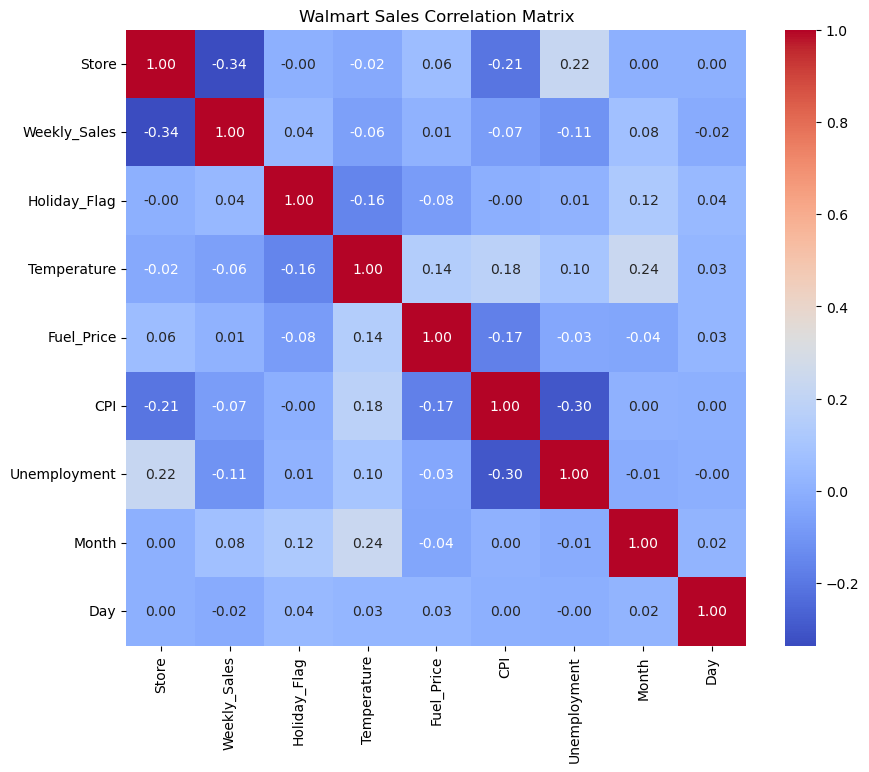

In [23]:
#correlation matrix
plt.figure(figsize=(10, 8))

corr = df.drop(columns=['Date']).corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Walmart Sales Correlation Matrix")
plt.show()

In [24]:
# we need to dummify store id and month, else they will be treated as continuous. Dummyfing day status to differentiate btw the 3 times in month)
df_encoded = pd.get_dummies(df, columns=['Store', 'Month','Day_Status'], drop_first=True, dtype=int)
df_encoded

x = df_encoded.drop(columns=['Date', 'Weekly_Sales','Day'])
y = df_encoded['Weekly_Sales']

x = sm.add_constant(x)

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [26]:
model_sm = sm.OLS(y_train, x_train).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     1394.
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        08:10:04   Log-Likelihood:                -76869.
No. Observations:                5791   AIC:                         1.539e+05
Df Residuals:                    5728   BIC:                         1.543e+05
Df Model:                          62                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    1

In [27]:
#Calculating mape.
y_pred_train = model_sm.predict(x_train)
y_pred_test = model_sm.predict(x_test)

mape_train = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100
mape_test = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print(f"Train MAPE: {mape_train:.2f}%")
print(f"Test MAPE: {mape_test:.2f}%")

Train MAPE: 9.12%
Test MAPE: 9.86%


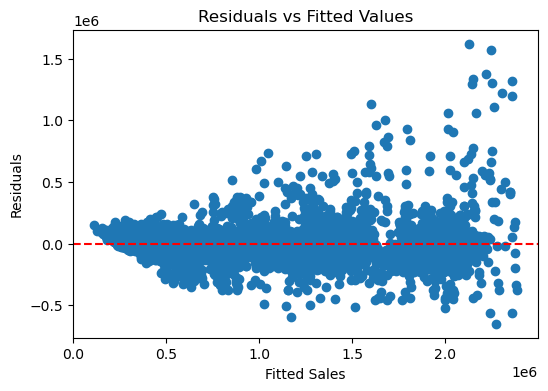

In [28]:
plt.figure(figsize=(6, 4))
plt.scatter(model_sm.fittedvalues, model_sm.resid)
plt.xlabel("Fitted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.axhline(y=0, color='red', linestyle='--')
plt.show()



## Heteroscedasticity detected

In [29]:
df_encoded = pd.get_dummies(df, columns=['Store', 'Month','Day_Status'], drop_first=True, dtype=int)
df_encoded

x = df_encoded.drop(columns=['Date', 'Weekly_Sales','Day'])
y = np.log(df_encoded['Weekly_Sales'])# logged to solve heteroscedasticity

x = sm.add_constant(x)

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

model_sm = sm.OLS(y_train, x_train).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     2770.
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        08:10:09   Log-Likelihood:                 4801.3
No. Observations:                5791   AIC:                            -9477.
Df Residuals:                    5728   BIC:                            -9057.
Df Model:                          62                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [31]:
#Prediction
y_pred_train_log = model_sm.predict(x_train)
y_pred_test_log = model_sm.predict(x_test)

#exponentiationg log to natural scale
y_pred_train_dollars = np.exp(y_pred_train_log)
y_pred_test_dollars = np.exp(y_pred_test_log)

y_train_dollars = np.exp(y_train)
y_test_dollars = np.exp(y_test)

#Calclating thr MAPE( Mean Average Percent Error)
mape_train = np.mean(np.abs((y_train_dollars - y_pred_train_dollars) / y_train_dollars)) * 100
mape_test = np.mean(np.abs((y_test_dollars - y_pred_test_dollars) / y_test_dollars)) * 100

print(f"Train MAPE (Real Dollars): {mape_train:.2f}%")
print(f"Test MAPE (Real Dollars): {mape_test:.2f}%")

Train MAPE (Real Dollars): 7.18%
Test MAPE (Real Dollars): 7.58%


# Homoscedasticity and Linearity detected

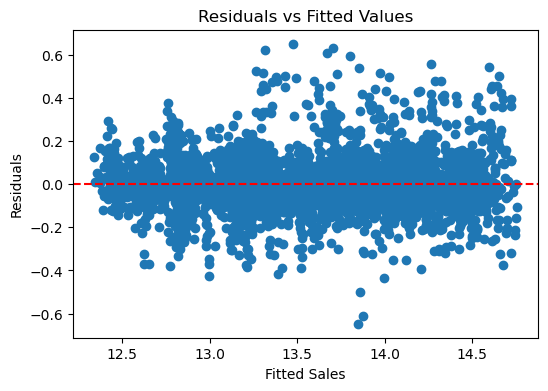

In [32]:
plt.figure(figsize=(6, 4))
plt.scatter(model_sm.fittedvalues, model_sm.resid)
plt.xlabel("Fitted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#multicollinearity checking
print('Variance Inflation Factors (VIF):')
print('(If VIF > 5, we have multicollinearity)')

vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

pd.set_option('display.max_rows', None)

print(vif_data)

Variance Inflation Factors (VIF):
(If VIF > 5, we have multicollinearity)
                    feature           VIF
0                     const  13633.453868
1              Holiday_Flag      1.230534
2               Temperature     12.324497
3                Fuel_Price      3.209167
4                       CPI    446.542685
5              Unemployment     16.618648
6                   Store_2      1.956249
7                   Store_3      2.022939
8                   Store_4     52.752452
9                   Store_5      2.120923
10                  Store_6      2.043970
11                  Store_7      5.269453
12                  Store_8      2.193889
13                  Store_9      2.163884
14                 Store_10     50.443183
15                 Store_11      2.028112
16                 Store_12     45.460895
17                 Store_13     51.030704
18                 Store_14      7.368273
19                 Store_15     44.018003
20                 Store_16      6.050435
21

In [42]:
y_log = np.log(df_encoded['Weekly_Sales'])
x_final = x.drop(columns=['CPI'])
#im choosing not to remove unemployment, eventhough its VIF is high, bcs it is a significant variable (p<0.05) & is important to measure recession risk to walmart

x_train, x_test, y_train_log, y_test_log = train_test_split(x_final, y_log, test_size=0.1, random_state=42)


final_model = sm.OLS(y_train_log, x_train).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     2816.
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        10:00:58   Log-Likelihood:                 4801.0
No. Observations:                5791   AIC:                            -9478.
Df Residuals:                    5729   BIC:                            -9065.
Df Model:                          61                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [43]:
y_pred_train_log = final_model.predict(x_train)
y_pred_test_log = final_model.predict(x_test)

In [44]:
y_pred_train_dollars = np.exp(y_pred_train_log)
y_pred_test_dollars = np.exp(y_pred_test_log)

y_train_dollars = np.exp(y_train_log)
y_test_dollars = np.exp(y_test_log)

train_mape = np.mean(np.abs((y_train_dollars - y_pred_train_dollars) / y_train_dollars)) * 100
test_mape = np.mean(np.abs((y_test_dollars - y_pred_test_dollars) / y_test_dollars)) * 100

print("\n--- FINAL ACCURACY REPORT (Real Dollars) ---")
print(f"Train MAPE: {train_mape:.2f}%")
print(f"Test MAPE:  {test_mape:.2f}%")


--- FINAL ACCURACY REPORT (Real Dollars) ---
Train MAPE: 7.18%
Test MAPE:  7.58%


In [45]:
from sklearn.metrics import r2_score

test_r2 = r2_score(y_test, final_model.predict(x_test))

print(f"Training R2: {final_model.rsquared:.3f}") # From the summary
print(f"Testing R2:  {test_r2:.3f}")

Training R2: 0.968
Testing R2:  0.968


In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

print('Variance Inflation Factors (VIF) - Final Model:')
print('(If VIF > 5, check for multicollinearity)')

vif_data = pd.DataFrame()
vif_data["feature"] = x_final.columns
vif_data["VIF"] = [variance_inflation_factor(x_final.values, i) for i in range(len(x_final.columns))]

pd.set_option('display.max_rows', None)
print(vif_data.sort_values('VIF', ascending=False))

Variance Inflation Factors (VIF) - Final Model:
(If VIF > 5, check for multicollinearity)
                    feature         VIF
0                     const  608.625592
4              Unemployment   14.060454
2               Temperature   12.291152
54                  Month_7    8.147862
55                  Month_8    7.557062
53                  Month_6    6.621367
56                  Month_9    6.156116
15                 Store_12    4.944549
41                 Store_38    4.944549
31                 Store_28    4.944549
52                  Month_5    4.500743
57                 Month_10    4.083882
51                  Month_4    3.823922
43                 Store_40    2.925398
26                 Store_23    2.887987
50                  Month_3    2.880010
10                  Store_7    2.672684
32                 Store_29    2.592030
19                 Store_16    2.500507
37                 Store_34    2.489817
29                 Store_26    2.464418
20                 Store_17   

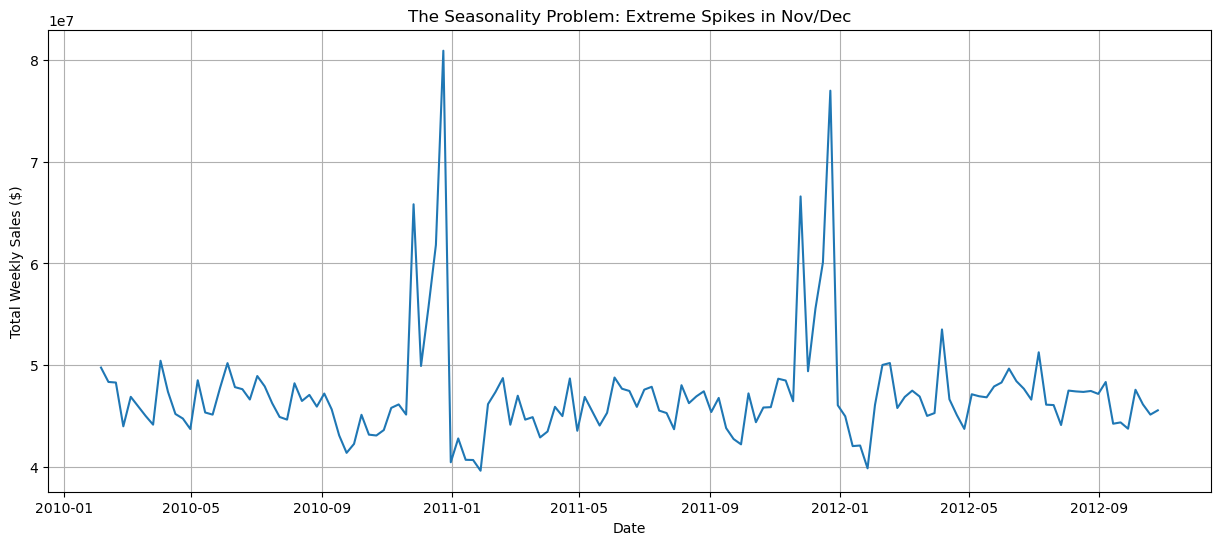

In [47]:
plt.figure(figsize=(15, 6))
time_data = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

sns.lineplot(data=time_data, x='Date', y='Weekly_Sales')
plt.title("The Seasonality Problem: Extreme Spikes in Nov/Dec")
plt.ylabel("Total Weekly Sales ($)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

C:\Users\Roshan Prakash\AppData\Local\Temp\ipykernel_7956\372003858.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Store', y='Weekly_Sales', order=sorted_index, palette='viridis')


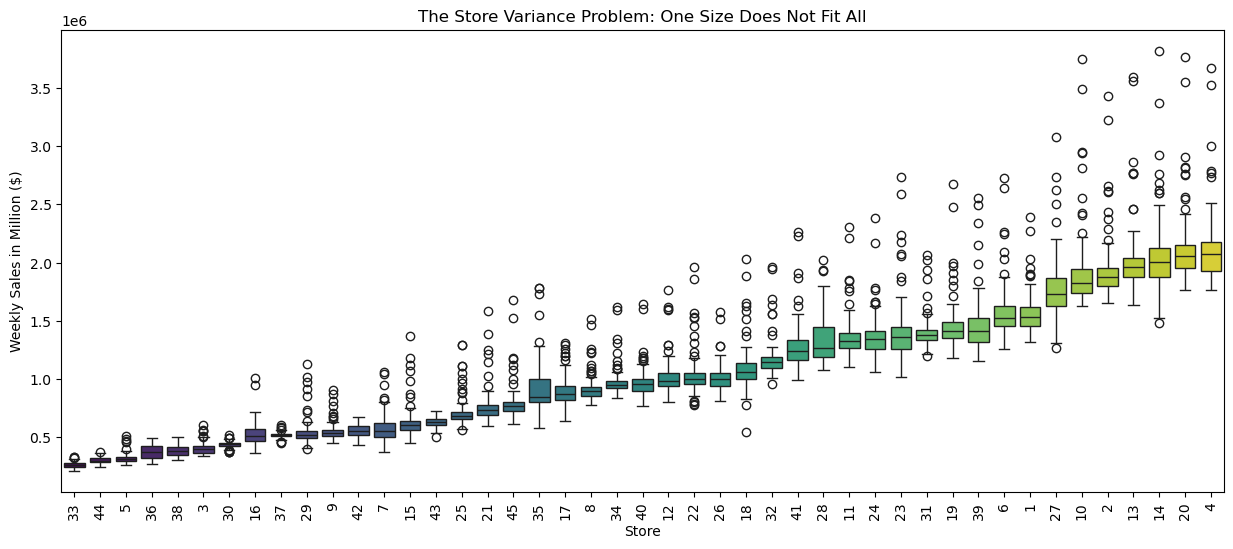

In [41]:
plt.figure(figsize=(15, 6))

sorted_index = df.groupby('Store')['Weekly_Sales'].median().sort_values().index

sns.boxplot(data=df, x='Store', y='Weekly_Sales', order=sorted_index, palette='viridis')
plt.title("The Store Variance Problem: One Size Does Not Fit All")
plt.ylabel("Weekly Sales in Million ($)")
plt.xticks(rotation=90)
plt.show()